# Klasyfikacja klientów bankowych (klasyfikacja)

Na podstawie danych klienta (wiek, zarobki, saldo, kredyt) ze zbioru **Bank Marketing Dataset (UCI)** proszę przewidzieć, czy kupi produkt finansowy.

🔗 **Link do bazy danych:** [https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip](https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip)

---

### 🛠️ Wymagania techniczne i algorytmy

* **Toolboxy:** `NumPy`, `pandas`, `matplotlib`, `scikit-learn` oraz `tensorflow`.
* **Algorytmy:** `MLPClassifier`, `RandomForestClassifier`, `SVC`, `KNeighborsClassifier`.
* **Środowisko dla MLP:** Colba GPU (tensorflow).

---

### 📋 Zadania do wykonania

1. **Optymalizacja i ewaluacja:**
   * Wykorzystać `GridSearchCV` dla każdego modelu.
   * Usunąć cechy o niskiej korelacji z celem.
   * Dokonać zamiany "y" na "tak/nie" przy interpretacji wyników.
   * Zoptymalizować liczbę warstw MLP i neuronów w nich się znajdujących.
   * Zoptymalizować liczbę drzew w RandomForest.
2. **Analiza końcowa:**
   * Jakie funkcje aktywacji oraz jądra dają najlepsze wyniki dla zadanego problemu?

---

### ⚠️ ! Uwaga

* **#1** Projekty zaliczeniowe proszę przygotować w **google colab**.
* **#2** Oprócz programu proszę przygotować **raport z wykonania projektu**, który będzie przechowywał dokładne informacje o charakterze zbioru, na którym zostały dokonane obliczenia (tabela z pierwszymi pięcioma przykładami w tablicy, rozkład cech, itp.). W raporcie powinna znaleźć się również informacja o tym, w jaki sposób wybrane algorytmy ml przetwarzają dane wejściowe. Rozdział dot. optymalizacja algorytmów i ich testowania dla różnych wartości parametrów również powinien się tu znaleźć.

# 1 Konfiguracja środowiska

## 1.1 Google Colab

In [3]:
from google.colab import drive
import os
drive.mount('/content/drive')
sciezka = '/content/drive/MyDrive/Colab Notebooks/ML_lab/ML_projekt/'
os.makedirs(sciezka, exist_ok=True)
os.chdir(sciezka)
print("Obecny folder to:", os.getcwd())

Mounted at /content/drive
Obecny folder to: /content/drive/MyDrive/Colab Notebooks/ML_lab/ML_projekt


##1.2 Lokalnie

In [ ]:
#import os
# Przyklad:
# sciezka_lokalna = 'D:/Projekty/'
# os.makedirs(sciezka_lokalna, exist_ok=True)
# os.chdir(sciezka_lokalna)

#print("Obecny folder to:", os.getcwd())

# 2 Importy

In [ ]:
# --- Podstawy: praca na danych ---
import numpy as np                 # operacje numeryczne
import pandas as pd                # wczytywanie i obrobka
import time                        # badanie czasu
import scipy.sparse                # obsluga macierzy rzadkich (niezbedne dla TensorFlow/Keras)
import joblib                      # zapis i odczyt modeli sklearn (.pkl)
import glob                        # odczyt modeli sklearn

# --- Wizualizacja ---
import matplotlib.pyplot as plt        # podstawowe wykresy
import seaborn as sns                  # wykresy statystyczne (np. heatmapa korelacji)
import matplotlib.gridspec as gridspec # precyzyjne rozmieszczanie wykresów (grid)

# --- Podzial danych i walidacja ---
from sklearn.model_selection import (
    train_test_split,              # podzial na zbior treningowy / testowy
    GridSearchCV,                  # strojenie hiperparametrow + walidacja krzyzowa
    StratifiedKFold,               # walidacja krzyzowa zachowujaca proporcje klas
    cross_val_score,               # szybka ocena modelu walidacja krzyzowa
    cross_val_predict,             # predykcje out-of-fold
)

# --- Przetwarzanie cech (preprocessing) ---
from sklearn.preprocessing import StandardScaler    # skalowanie cech numerycznych (srednia 0, odch. 1)
from sklearn.preprocessing import OneHotEncoder     # kodowanie cech kategorycznych na kolumny 0/1
from sklearn.compose import ColumnTransformer       # rozne transformacje dla roznych kolumn (num vs kat)
from sklearn.pipeline import Pipeline               # spina preprocessing + model w jeden obiekt (bez leakage)
from sklearn.pipeline import Pipeline as SkPipeline # pipeline bez SMOTE (dla RF i SVC)
from sklearn.impute import SimpleImputer            # uzupelnianie brakow (jesli wystapia)

# --- Obsługa niezbalansowania (imbalanced-learn) ---
from imblearn.pipeline import Pipeline as ImbPipeline   # pipeline z krokiem resamplingu
from imblearn.over_sampling import SMOTE                # oversampling klasy mniejszościowej

# --- Wybor najwazniejszych cech ---
from sklearn.feature_selection import SelectKBest, f_classif  # wybor k najlepszych cech

# --- Modele (sklearn) ---
from sklearn.neural_network import MLPClassifier      # siec neuronowa (sklearn)
from sklearn.ensemble import RandomForestClassifier   # las losowy
from sklearn.svm import SVC                           # maszyna wektorow nosnych
from sklearn.neighbors import KNeighborsClassifier    # k najblizszych sasiadow

# --- Model (TensorFlow / Keras) — siec neuronowa na GPU ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# --- Metryki / ocena ---
from sklearn.metrics import (
    classification_report,          # precision / recall / f1 dla kazdej klasy
    confusion_matrix,               # macierz pomylek (liczby)
    ConfusionMatrixDisplay,         # rysowanie macierzy pomylek
    f1_score,                       # metryka wiodaca (F1-macro – zbior niezbalansowany)
    accuracy_score,                 # dokladnosc (test na "naiwnosc")
    roc_auc_score,                  # pole pod krzywa ROC (ogolna zdolnosc do rankingu)
    RocCurveDisplay,                # rysowanie krzywej ROC
    precision_score,                # trafnosc (ile z wytypowanych "TAK" to sukcesy)
    recall_score,                   # czulosc (ile wszystkich "TAK" model odkryl)
    average_precision_score,        # pole pod krzywa PR-AUC (ranking dla klasy mniejszosciowej)
    brier_score_loss,                # ocena kalibracji (jak ufac procentom z modelu)
    roc_curve,                      # krzywa ROC w wykresach
    precision_recall_curve,         # krzywa PR + threshold tuning
)


# --- Ustawienia globalne ---
import warnings
warnings.filterwarnings("ignore")            # czytelniejszy output
pd.set_option("display.max_columns", None)   # pokazuj wszystkie kolumny
RANDOM_STATE = 42                            # ziarno losowosci -> powtarzalnosc wynikow

print("Importy OK | TensorFlow:", tf.__version__)

Importy OK | TensorFlow: 2.20.0


# 3 Eksploracja i analiza danych (EDA)

## 3.1 Wczytanie, opis zbioru i scieżki zapisów

In [ ]:
# Wczytanie danych
try:
    df_bank = pd.read_csv(
        'dane/bank-additional-full.csv',
        sep=';',
        encoding='utf-8'
    )
    print(f"✅ Sukces: Wczytano zbiór danych o wymiarach: {df_bank.shape}")

    # Wyświetlenie pierwszych 3 wierszy w celu weryfikacji poprawności wczytania
    display(df_bank.head(3))
except FileNotFoundError:
    print("❌ Błąd: Nie znaleziono pliku. Sprawdź ścieżkę do pliku csv.")

sciezka_modeli   = os.path.join(sciezka, 'modele')
sciezka_wykresow = os.path.join(sciezka, 'wykresy')
os.makedirs(sciezka_modeli,   exist_ok=True)
os.makedirs(sciezka_wykresow, exist_ok=True)

✅ Sukces: Wczytano zbiór danych o wymiarach: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3.2 Opis zmiennych

**Cel**

| Zmienna | Typ | Opis |
|:--|:--|:--|
| `y` | binarna (`yes`/`no`) | Czy klient założył lokatę terminową po kampanii.|

**Cechy klienta**

| # | Zmienna | Typ | Opis |
|:--:|:--|:--|:--|
| 1 | `age` | numeryczna | Wiek klienta w latach|
| 2 | `job` | kategoryczna | Rodzaj wykonywanej pracy|
| 3 | `marital` | kategoryczna | Stan cywilny|
| 4 | `education` | kategoryczna | Poziom wykształcenia|
| 5 | `default` | kategoryczna | Czy klient ma kredyt w stanie niespłacania|
| 6 | `housing` | kategoryczna | Czy klient ma kredyt mieszkaniowy/hipoteczny|
| 7 | `loan` | kategoryczna | Czy klient ma kredyt gotówkowy (osobisty)|

**Cechy ostatniego kontaktu**

| # | Zmienna | Typ | Opis |
|:--:|:--|:--|:--|
| 8 | `contact` | kategoryczna |Rodzaj kontaktu|
| 9 | `month` | kategoryczna | Miesiąc ostatniego kontaktu w roku|
| 10 | `day_of_week` | kategoryczna | Dzień tygodnia ostatniego kontaktu|
| 11 | `duration` | numeryczna | Czas trwania ostatniej rozmowy w sekundach|

**Cechy historii kampanii**

| # | Zmienna | Typ | Opis |
|:--:|:--|:--|:--|
| 12 | `campaign` | numeryczna | Liczba kontaktów z tym klientem w bieżącej kampanii (łącznie z ostatnim)|
| 13 | `pdays` | numeryczna | Liczba dni od ostatniego kontaktu z poprzedniej kampanii. **`999` = klient nie był wcześniej kontaktowany** (kod specjalny, nie realna liczba dni)|
| 14 | `previous` | numeryczna | Liczba kontaktów z tym klientem zrealizowanych **przed** bieżącą kampanią|
| 15 | `poutcome` | kategoryczna | Wynik poprzedniej kampanii marketingowej|

**Cechy kontekstu społeczno-ekonomicznego** (wskaźniki ogólnokrajowe nie dotyczą pojedynczego klienta, lecz koniunktury w danym okresie)

| # | Zmienna | Typ | Opis |
|:--:|:--|:--|:--|
| 16 | `emp.var.rate` | numeryczna | Stopa zmienności zatrudnienia wskaźnik **kwartalny** koniunktury na rynku pracy|
| 17 | `cons.price.idx` | numeryczna | Indeks cen konsumpcyjnych (CPI) wskaźnik **miesięczny**, miara inflacji|
| 18 | `cons.conf.idx` | numeryczna | Indeks zaufania konsumentów - wskaźnik **miesięczny** nastrojów gospodarstw domowych|
| 19 | `euribor3m` | numeryczna | Stawka EURIBOR 3-miesięczna - **dzienny** wskaźnik oprocentowania pożyczek międzybankowych|
| 20 | `nr.employed` | numeryczna | Liczba zatrudnionych w gospodarce (w tysiącach) - wskaźnik **kwartalny**. |



## 3.3 Analiza braków

In [ ]:
braki = (df_bank == "unknown").sum()
braki = braki[braki > 0].sort_values(ascending=False)
procent = (braki / len(df_bank) * 100).round(2)
display(pd.DataFrame({"Liczba 'unknown'": braki, "Procent [%]": procent}))

,Liczba 'unknown',Procent [%]
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


### **Wnioski z analizy braków**

  Braki występują wyłącznie w cechach kategorycznych i są zakodowane jako `"unknown"`. Ich udział jest bardzo nierówny:
  
  - **`default` - 20.87% (8597)**: usunięcie tych wierszy oznaczałoby utratę co piątego klienta, a imputacja najczęstszą wartością (`no`) byłaby zmyślaniem informacji. Co istotne - to, że klient **nie ujawnił** statusu kredytu, samo w sobie może korelować z decyzją o lokacie.
  - **`education` (4.20%), `housing` i `loan` (po 2.40%), `job` (0.80%), `marital` (0.19%)**: udziały małe, ale dla spójności traktujemy je tak samo.

  **Wniosek:** braków **nie usuwamy** i **nie imputujemy** - zostawiamy `"unknown"` jako **osobną kategorię**. Dzięki temu nie tracimy ~20% danych.

## 3.4 Podział zmiennych na numeryczne i kategoryczne

In [ ]:
num_cols = df_bank.select_dtypes(include='number').columns.tolist()
cat_cols = df_bank.select_dtypes(include='object').columns.drop('y').tolist()

print("Zmienne numeryczne:", num_cols)
print("\nZmienne kategoryczne:", cat_cols)

Zmienne numeryczne: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Zmienne kategoryczne: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


## 3.5 Analiza zmiennych numerycznych

In [ ]:
# Definicja funkcji analizy statystycznej (metoda IQR)
def outlier_stats_iqr(series):
    data = series.dropna()

    if len(data) == 0:
        return None

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask_out = (data < lower) | (data > upper)
    outlier_idx = data.index[mask_out]

    return {
        # STATYSTYKI PODSTAWOWE
        "min": float(data.min()),
        "max": float(data.max()),
        "mean": float(data.mean()),
        "median": float(data.median()),

        # KWARTYLE I IQR
        "Q1": float(Q1),
        "Q3": float(Q3),
        "IQR": float(IQR),

        # PROGI DLA OUTLIERÓW
        "lower_bound": float(lower),
        "upper_bound": float(upper),

        # STATYSTYKI OUTLIERÓW
        "n_outliers": int(mask_out.sum()),
        "percent_outliers": 100 * int(mask_out.sum()) / len(data),

        # SZCZEGÓŁY OUTLIERÓW
        "outlier_idx": list(outlier_idx),
        "outlier_values": list(data[mask_out]),
        "mask_outlier": mask_out
    }


# Tabela: statystyki + outliery
rows = []
for col in num_cols:
    s = outlier_stats_iqr(df_bank[col])
    rows.append({
        'zmienna': col,
        'min': s['min'], 'max': s['max'],
        'mean': round(s['mean'], 2), 'median': s['median'],
        'Q1': s['Q1'], 'Q3': s['Q3'], 'IQR': s['IQR'],
        'próg_dolny': s['lower_bound'], 'próg_górny': s['upper_bound'],
        'n_outlier': s['n_outliers'], '%_outlier': round(s['percent_outliers'], 1),
    })

tabela_outlier = pd.DataFrame(rows).set_index('zmienna')
display(tabela_outlier)


,min,max,mean,median,Q1,Q3,IQR,próg_dolny,próg_górny,n_outlier,%_outlier
zmienna,,,,,,,,,,,
age,17.000,98.000,40.02,38.000,32.000,47.000,15.000,9.5000,69.5000,469,1.1
duration,0.000,4918.000,258.29,180.000,102.000,319.000,217.000,-223.5000,644.5000,2963,7.2
campaign,1.000,56.000,2.57,2.000,1.000,3.000,2.000,-2.0000,6.0000,2406,5.8
pdays,0.000,999.000,962.48,999.000,999.000,999.000,0.000,999.0000,999.0000,1515,3.7
previous,0.000,7.000,0.17,0.000,0.000,0.000,0.000,0.0000,0.0000,5625,13.7
emp.var.rate,-3.400,1.400,0.08,1.100,-1.800,1.400,3.200,-6.6000,6.2000,0,0.0
cons.price.idx,92.201,94.767,93.58,93.749,93.075,93.994,0.919,91.6965,95.3725,0,0.0
cons.conf.idx,-50.800,-26.900,-40.50,-41.800,-42.700,-36.400,6.300,-52.1500,-26.9500,447,1.1
euribor3m,0.634,5.045,3.62,4.857,1.344,4.961,3.617,-4.0815,10.3865,0,0.0


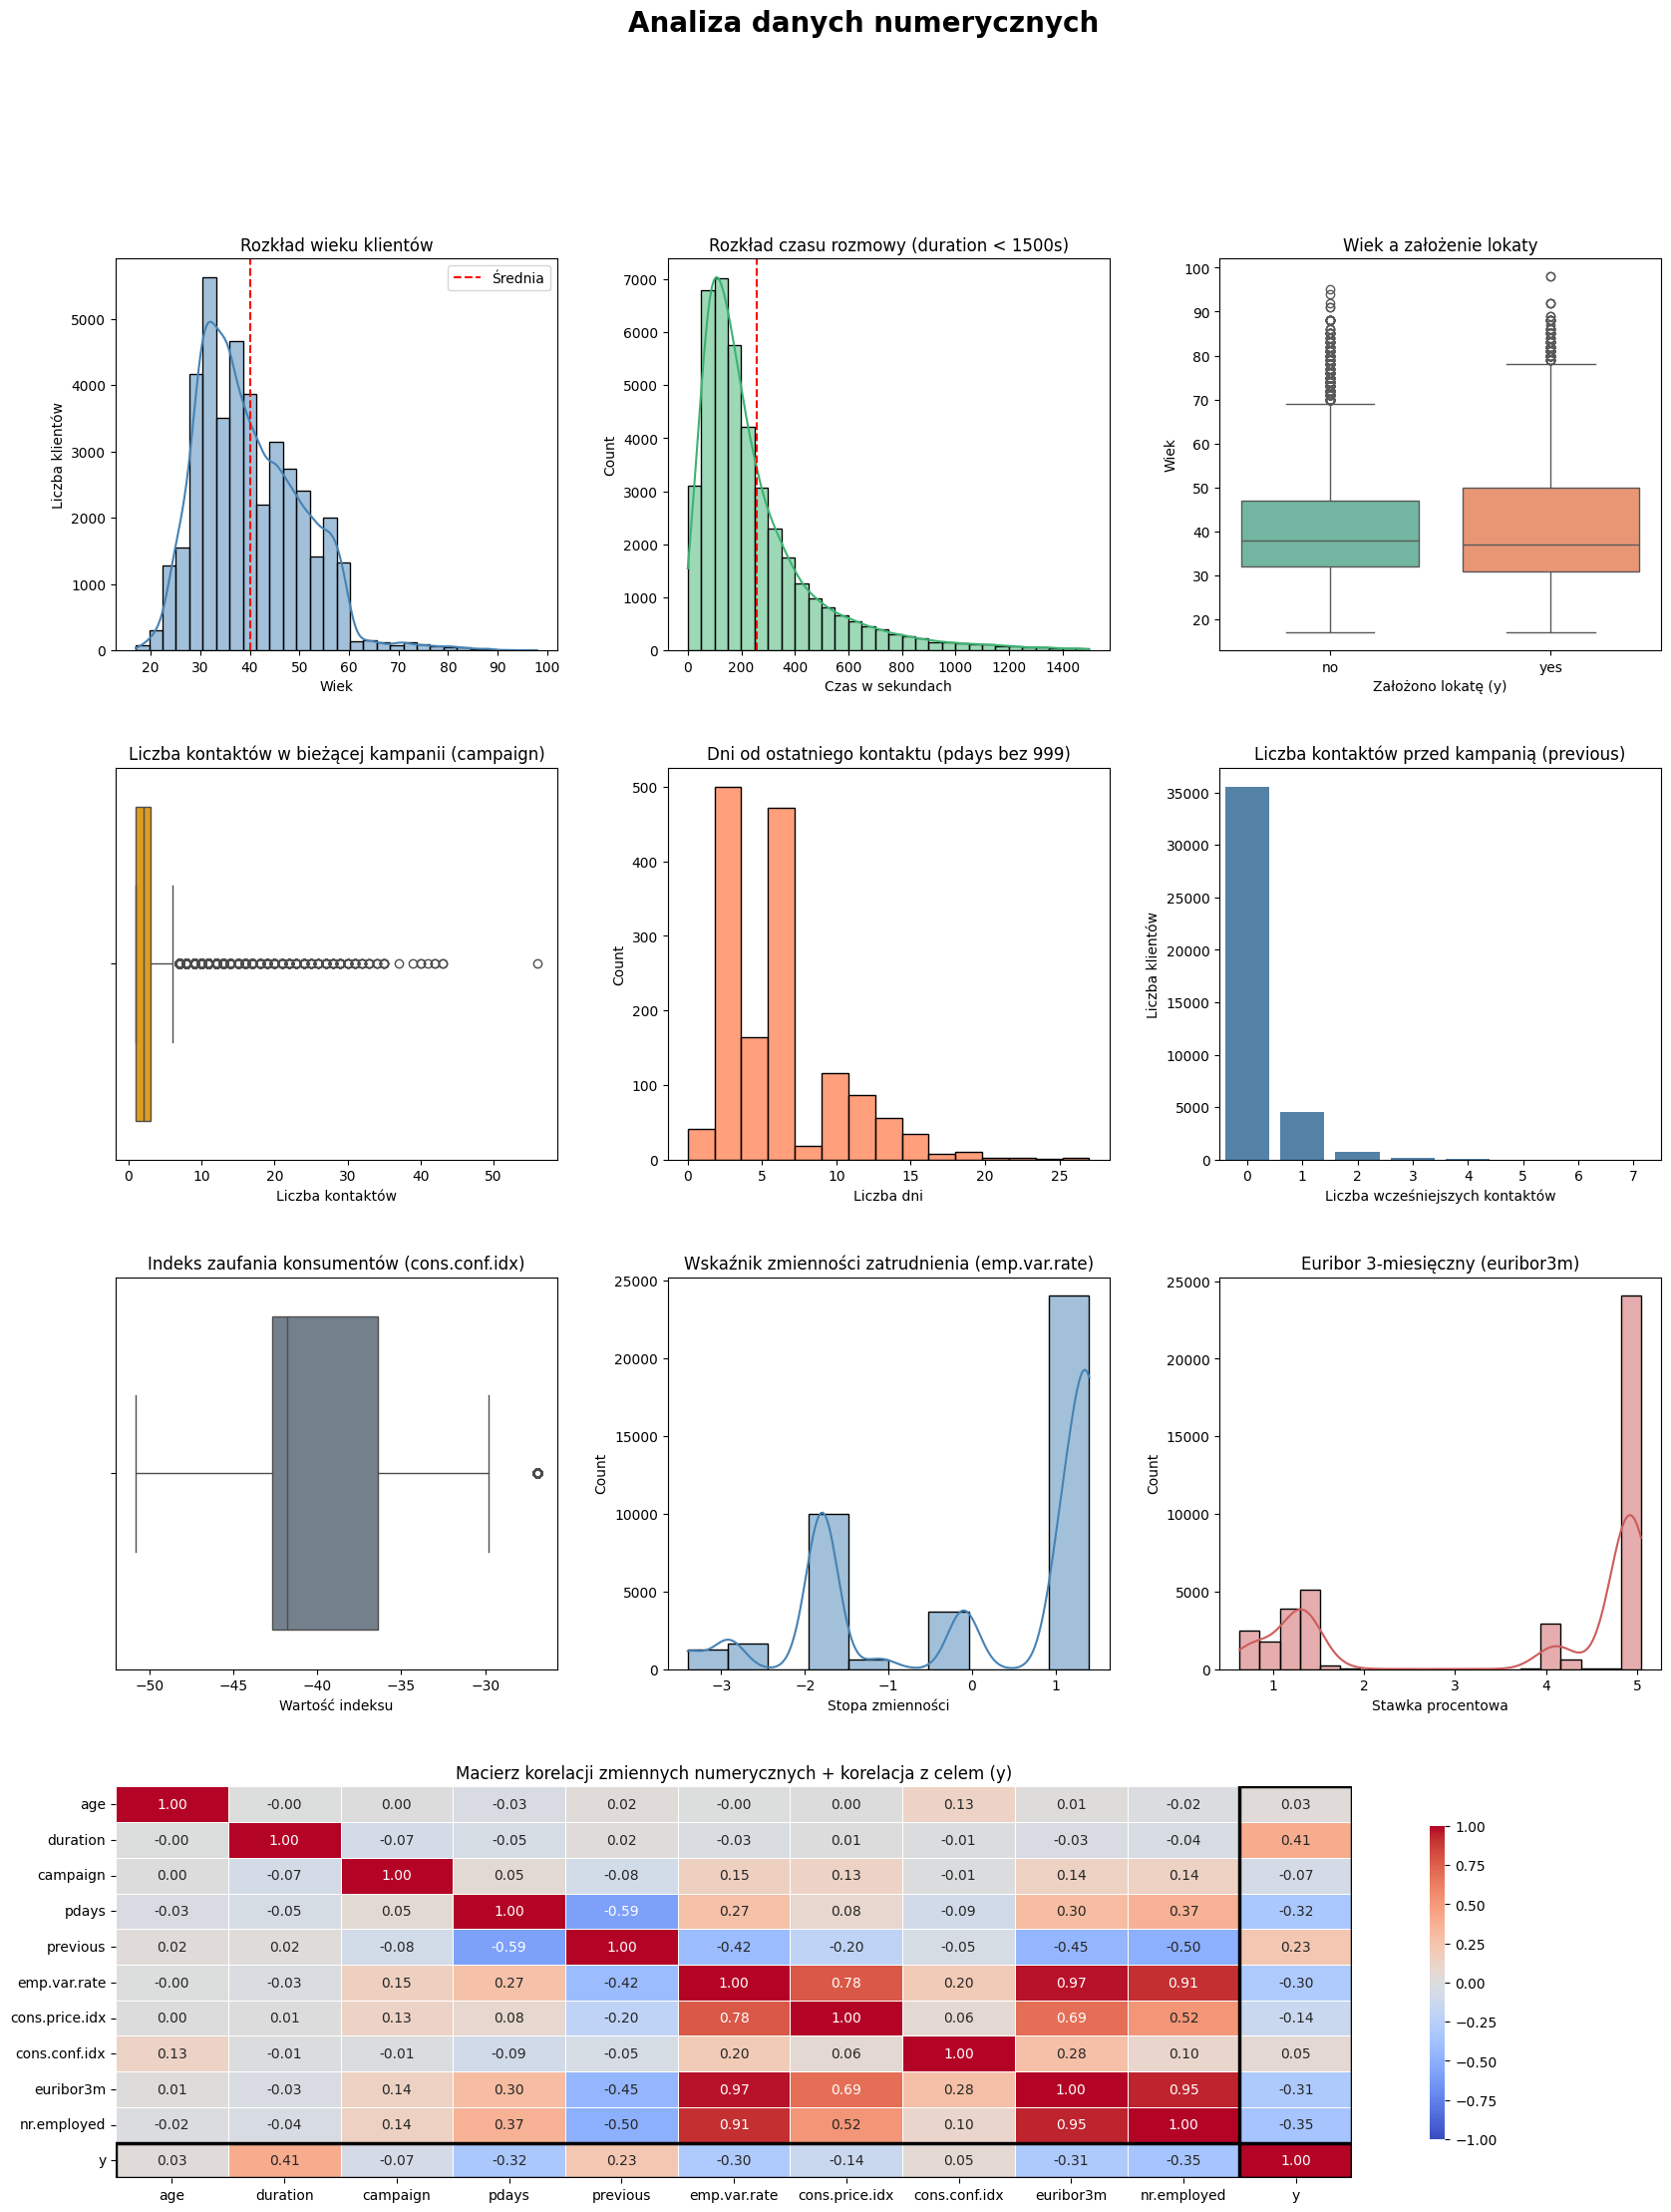

In [ ]:
# Inicjalizacja figury i siatki (GridSpec)
fig = plt.figure(figsize=(20, 25))
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.3, wspace=0.25)

# =========================
# WIERSZ 1 – DEMOGRAFIA I KONTAKT
# =========================

# 1. Rozkład wieku
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(df_bank['age'], bins=30, kde=True, color="steelblue", ax=ax1)
ax1.axvline(df_bank['age'].mean(), color="red", linestyle="--", label="Średnia")
ax1.set_title("Rozkład wieku klientów")
ax1.set_xlabel("Wiek")
ax1.set_ylabel("Liczba klientów")
ax1.legend()

# 2. Czas trwania rozmowy (ucięty do 1500s dla czytelności)
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(df_bank[df_bank['duration'] < 1500]['duration'], bins=30, kde=True, color="mediumseagreen", ax=ax2)
ax2.axvline(df_bank['duration'].mean(), color="red", linestyle="--", label="Średnia")
ax2.set_title("Rozkład czasu rozmowy (duration < 1500s)")
ax2.set_xlabel("Czas w sekundach")

# 3. Wiek a decyzja (y)
ax3 = fig.add_subplot(gs[0, 2])
sns.boxplot(
    data=df_bank,
    x="y",
    y="age",
    palette="Set2",
    ax=ax3
)
ax3.set_title("Wiek a założenie lokaty")
ax3.set_xlabel("Założono lokatę (y)")
ax3.set_ylabel("Wiek")

# =========================
# WIERSZ 2 – HISTORIA KAMPANII
# =========================

# 4. Boxplot kampanii (wykrywanie outlierów)
ax4 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=df_bank, x="campaign", color="orange", ax=ax4)
ax4.set_title("Liczba kontaktów w bieżącej kampanii (campaign)")
ax4.set_xlabel("Liczba kontaktów")

# 5. Dni od poprzedniego kontaktu (pdays bez 999)
ax5 = fig.add_subplot(gs[1, 1])
sns.histplot(df_bank[df_bank['pdays'] != 999]['pdays'], bins=15, kde=False, color="coral", ax=ax5)
ax5.set_title("Dni od ostatniego kontaktu (pdays bez 999)")
ax5.set_xlabel("Liczba dni")

# 6. Liczba wcześniejszych kontaktów (previous)
ax6 = fig.add_subplot(gs[1, 2])
sns.countplot(data=df_bank, x="previous", color="steelblue", ax=ax6)
ax6.set_title("Liczba kontaktów przed kampanią (previous)")
ax6.set_xlabel("Liczba wcześniejszych kontaktów")
ax6.set_ylabel("Liczba klientów")

# =========================
# WIERSZ 3 – WSKAŹNIKI MAKROEKONOMICZNE
# =========================

# 7. Indeks zaufania konsumentów
ax7 = fig.add_subplot(gs[2, 0])
sns.boxplot(data=df_bank, x="cons.conf.idx", color="slategray", ax=ax7)
ax7.set_title("Indeks zaufania konsumentów (cons.conf.idx)")
ax7.set_xlabel("Wartość indeksu")

# 8. Wskaźnik zatrudnienia
ax8 = fig.add_subplot(gs[2, 1])
sns.histplot(df_bank['emp.var.rate'], bins=10, kde=True, color="steelblue", ax=ax8)
ax8.set_title("Wskaźnik zmienności zatrudnienia (emp.var.rate)")
ax8.set_xlabel("Stopa zmienności")

# 9. Euribor 3M
ax9 = fig.add_subplot(gs[2, 2])
sns.histplot(df_bank['euribor3m'], bins=20, kde=True, color="indianred", ax=ax9)
ax9.set_title("Euribor 3-miesięczny (euribor3m)")
ax9.set_xlabel("Stawka procentowa")

# =========================
# WIERSZ 4 – KORELACJE (z celem y)
# =========================

# 10. Macierz korelacji zmiennych numerycznych + cel (y jako 0/1)
ax10 = fig.add_subplot(gs[3, :])

# cel zakodowany binarnie jako ostatnią kolumnę
corr_data = df_bank[num_cols].copy()
corr_data['y'] = df_bank['y'].map({'yes': 1, 'no': 0})
corr_matrix = corr_data.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    ax=ax10
)
ax10.set_title("Macierz korelacji zmiennych numerycznych + korelacja z celem (y)")

# Obramowanie wiersza i kolumny 'y', żeby się wyróżniały
n = len(corr_matrix)
ax10.add_patch(plt.Rectangle((0, n - 1), n, 1, fill=False, edgecolor='black', lw=2.5))  # wiersz y
ax10.add_patch(plt.Rectangle((n - 1, 0), 1, n, fill=False, edgecolor='black', lw=2.5))  # kolumna y

# =========================
# TYTUŁ
# =========================
fig.suptitle(
    "Analiza danych numerycznych",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(os.path.join(sciezka_wykresow, 'analiza_numeryczna.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### **Wnioski z analizy zmiennych numerycznych**

**1. `age` (wiek)**
* Na histogramie większość klientów mieści się między 30 a 50 lat, potem liczebność szybko spada.
* Outlierów jest mało (ok. 1%) i wszystkie są górne, czyli to realni seniorzy, nie błędy.
* W macierzy korelacja z celem jest praktycznie zerowa (0.03), co potwierdza brak liniowego sygnału.
* **Wniosek:** liniowo wiek prawie nie koreluje (0.03), ale sygnał jest nieliniowy. Zostawiamy i robimy podział na grupy wiekowe.

**2. `duration` (czas rozmowy)**
* Histogram mocno rozciągnięty w prawo: dominują krótkie rozmowy, większość osób rozłącza się szybko.
* Średnia jest sporo wyższa od mediany, bo garść bardzo długich rozmów zawyża wynik. To też daje najwięcej outlierów w całym zbiorze (ponad 7%), wszystkie górne.
* W macierzy ma najwyższą korelację z celem w całym zbiorze (0.41), ale to właśnie objaw data leakage.
* **Wniosek:** usuwamy mimo najwyższej korelacji, bo czas rozmowy znamy dopiero po telefonie.

**3. `campaign` (liczba kontaktów)**
* Boxplot ma pudełko ściśnięte przy kilku kontaktach, mediana to raptem 2.
* Średnia jest wyższa, bo ciągną ją skrajne próby. Outliery (prawie 6%) to wartości powyżej progu wąsa, raczej „męczenie" klienta albo duplikaty w CRM.
* Korelacja z celem słaba i ujemna (-0.07): więcej prób, ciut mniejsza szansa.
* **Wniosek:** winsoryzacja do górnego wąsa. Predyktor słaby, ledwo nad progiem.

**4. `pdays` (dni od ostatniego kontaktu)**
* Wykres bez 999 dotyczy tylko garstki klientów, cała reszta nie miała wcześniejszego kontaktu. „Outliery" (niecałe 4%) to akurat te jedyne realne wartości.
* Korelacja z celem umiarkowana ujemna (-0.32), jedna z silniejszych, ale napędzana strukturą placeholdera 999.
* **Wniosek:** przekształcić na cechę kategoryczną („kontaktowany wcześniej: tak/nie"), co oczyszcza ten sygnał.

**5. `previous` (kontakty przed kampanią)**
* Prawie wszyscy mają zerową historię (dominująca wartość to 0). Wysoki odsetek „outlierów" (13.7%) to po prostu wszyscy klienci z jakąkolwiek historią (>0), nie anomalie.
* Mimo małej wariancji korelacja z celem jest zauważalna i dodatnia (0.23), jedna z wyższych wśród numerycznych. Kto był kontaktowany wcześniej, konwertuje lepiej.
* **Wniosek:** wbrew pozorom niesie realny sygnał, zostawiamy bez zmian.

**6. Wskaźniki makroekonomiczne (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`)**
* Outlierów praktycznie brak (0%), drobny wyjątek to `cons.conf.idx` (1.1% skupione na -26.9).
* To one mają najsilniejszą realną korelację z celem: `nr.employed` (-0.35), `euribor3m` (-0.31), `emp.var.rate` (-0.30), wszystkie ujemne, czyli gorsza koniunktura sprzyja lokatom. Wyjątkiem jest `cons.conf.idx` z korelacją bliską zera (0.05).
* Jednocześnie trójka `emp.var.rate`, `euribor3m`, `nr.employed` jest mocno współliniowa między sobą (0.91 do 0.97).
* **Wniosek:** usuwamy tylko `cons.conf.idx` (korelacja 0.05, praktycznie brak sygnału).

**7. Korelacja `pdays` i `previous` (-0.59)**
* Widoczna ujemna korelacja jest pozorna. Wynika wyłącznie ze sztucznego przypisania wartości 999 (`pdays`) dla osób bez wcześniejszego kontaktu, a nie z realnej zależności.

## 3.6 Analiza zmiennych kategorycznych

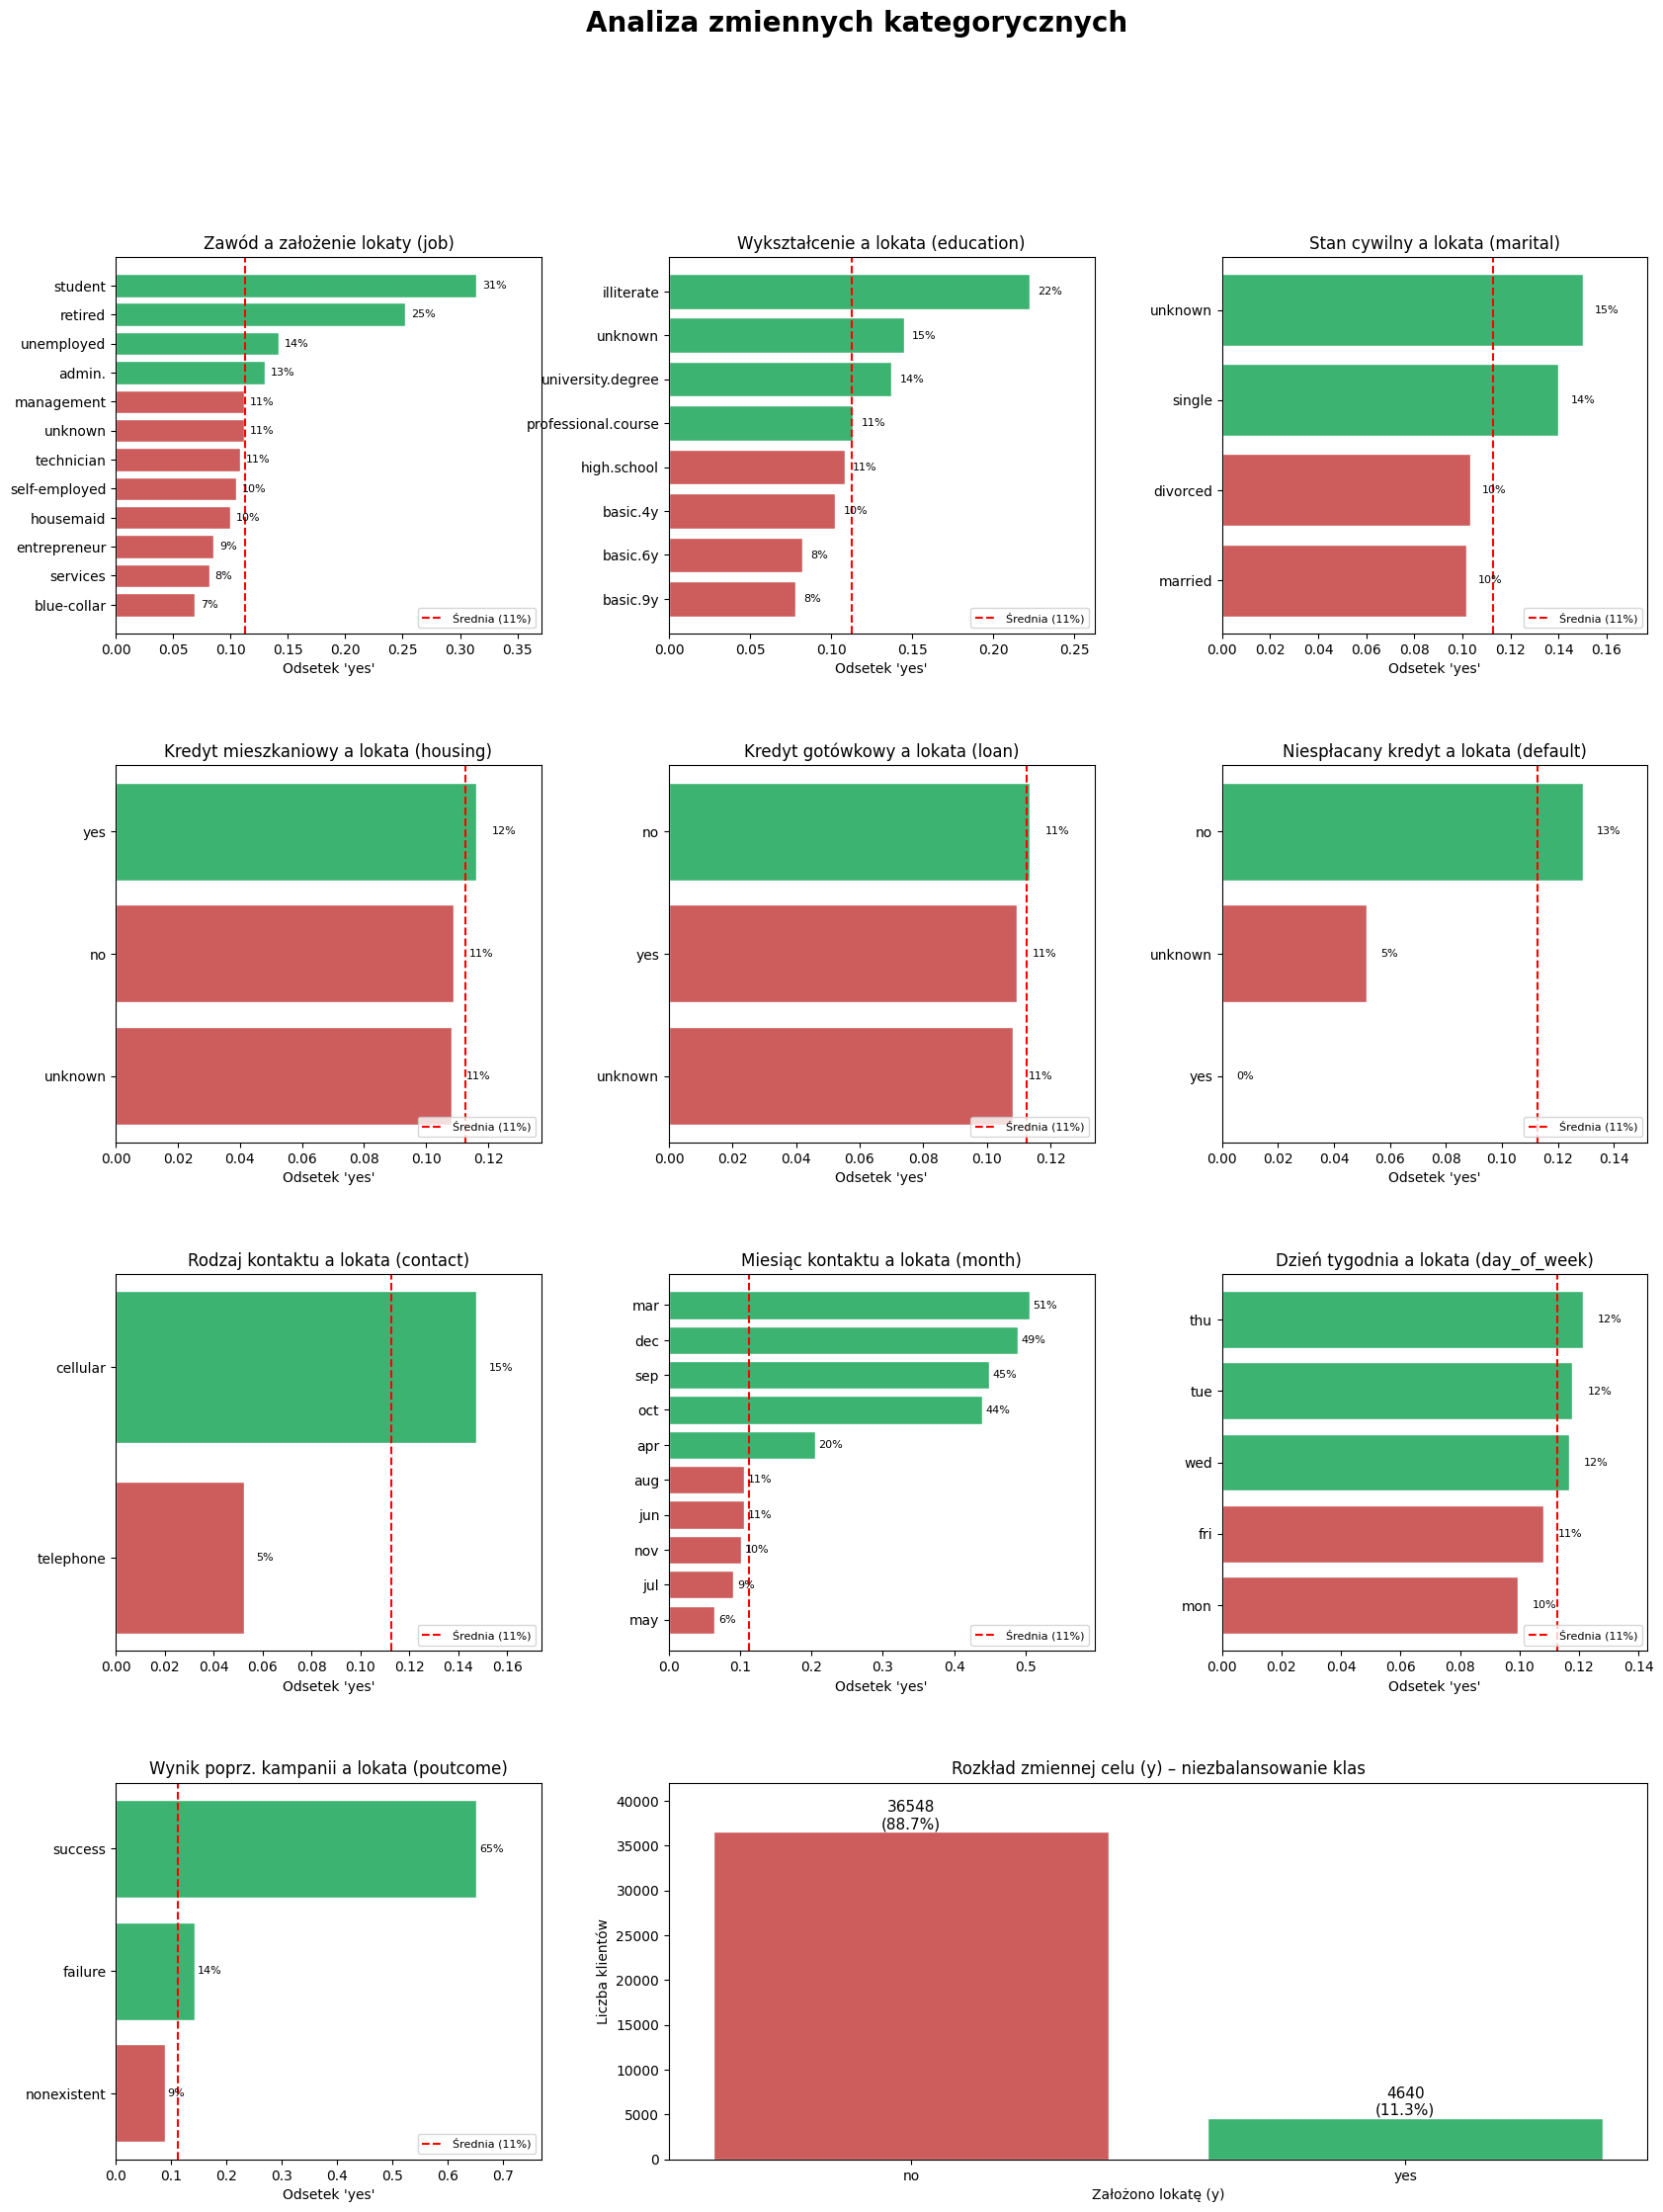

In [ ]:
# Średnia ogólna (linia odniesienia)
overall_rate = (df_bank['y'] == 'yes').mean()

# Funkcja pomocnicza: poziomy słupek z odsetkiem "yes" per kategoria
def barh_rate(ax, col, title):
    rate = (
        df_bank.groupby(col)['y']
        .apply(lambda s: (s == 'yes').mean())
        .sort_values()
    )
    colors = ['mediumseagreen' if v >= overall_rate else 'indianred' for v in rate.values]
    ax.barh(rate.index.astype(str), rate.values, color=colors, edgecolor='white')
    ax.axvline(overall_rate, color='red', linestyle='--', label=f'Średnia ({overall_rate:.0%})')
    # Etykiety wartości na końcach słupków
    for i, v in enumerate(rate.values):
        ax.text(v + 0.005, i, f'{v:.0%}', va='center', fontsize=8)
    ax.set_xlim(0, rate.max() * 1.18)
    ax.set_title(title)
    ax.set_xlabel("Odsetek 'yes'")
    ax.legend(loc='lower right', fontsize=8)


# Inicjalizacja figury i siatki (GridSpec)
fig = plt.figure(figsize=(20, 25))
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.35, wspace=0.3)

# =========================
# WIERSZ 1 – DEMOGRAFIA KLIENTA
# =========================
barh_rate(fig.add_subplot(gs[0, 0]), 'job',       "Zawód a założenie lokaty (job)")
barh_rate(fig.add_subplot(gs[0, 1]), 'education', "Wykształcenie a lokata (education)")
barh_rate(fig.add_subplot(gs[0, 2]), 'marital',   "Stan cywilny a lokata (marital)")

# =========================
# WIERSZ 2 – PRODUKTY KREDYTOWE
# =========================
barh_rate(fig.add_subplot(gs[1, 0]), 'housing', "Kredyt mieszkaniowy a lokata (housing)")
barh_rate(fig.add_subplot(gs[1, 1]), 'loan',    "Kredyt gotówkowy a lokata (loan)")
barh_rate(fig.add_subplot(gs[1, 2]), 'default', "Niespłacany kredyt a lokata (default)")

# =========================
# WIERSZ 3 – KONTAKT I CZAS
# =========================
barh_rate(fig.add_subplot(gs[2, 0]), 'contact',     "Rodzaj kontaktu a lokata (contact)")
barh_rate(fig.add_subplot(gs[2, 1]), 'month',       "Miesiąc kontaktu a lokata (month)")
barh_rate(fig.add_subplot(gs[2, 2]), 'day_of_week', "Dzień tygodnia a lokata (day_of_week)")

# =========================
# WIERSZ 4 – HISTORIA KAMPANII + ROZKŁAD CELU
# =========================

# poutcome – najsilniejszy sygnał kategoryczny
barh_rate(fig.add_subplot(gs[3, 0]), 'poutcome', "Wynik poprz. kampanii a lokata (poutcome)")

# Rozkład zmiennej celu (niezbalansowanie klas) – 2 kolumny
ax_y = fig.add_subplot(gs[3, 1:])
counts = df_bank['y'].value_counts()
bars = ax_y.bar(counts.index, counts.values, color=['indianred', 'mediumseagreen'], edgecolor='white')
for b, v in zip(bars, counts.values):
    ax_y.text(b.get_x() + b.get_width()/2, v, f'{v}\n({v/len(df_bank):.1%})',
              ha='center', va='bottom', fontsize=11)
ax_y.set_title("Rozkład zmiennej celu (y) – niezbalansowanie klas")
ax_y.set_xlabel("Założono lokatę (y)")
ax_y.set_ylabel("Liczba klientów")
ax_y.set_ylim(0, counts.max() * 1.15)

# =========================
# TYTUŁ
# =========================
fig.suptitle(
    "Analiza zmiennych kategorycznych",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(sciezka_wykresow, 'analiza_kategoryczna.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### **Wnioski z analizy zmiennych kategorycznych**

**1. `job`, `education`, `marital` (demografia)**
* `job` daje wyraźny sygnał: studenci i emeryci kupują dużo powyżej średniej, a blue-collar i services najmniej. `education` pokazuje prosty trend: im wyższe wykształcenie, tym wyższy odsetek (od ok. 8% przy podstawowym do 14% przy wyższym). `illiterate` (22%) odstaje, ale to 18 osób i to tylko szum. `marital` jest prawie płaski, single ledwo powyżej średniej.
* **Wniosek:** `job` zostawiamy jako mocną cechę, `education` warunkowo, `marital` to słaby kandydat.

**2. `housing`, `loan`, `default` (kredyty)**
* `housing` i `loan` są praktycznie płaskie, wszystkie kategorie ocierają się o średnią, więc nie różnicują klienta. `default` wygląda ciekawiej: „yes" praktycznie nie istnieje, a „unknown" ma zauważalnie niższy odsetek niż „no". Czyli sam fakt nieujawnienia statusu kredytu coś znaczy.
* **Wniosek:** `housing` i `loan` to kandydaci do wyrzucenia (zero sygnału), `default` warto zostawić mimo dziwnego rozkładu.

**3. `contact`, `month`, `day_of_week` (kontakt i czas)**
* `contact` daje mocny sygnał: telefon komórkowy konwertuje trzy razy lepiej niż stacjonarny. `month` ma ogromne wahania, marzec, grudzień, wrzesień i październik mają bardzo wysoki odsetek. `day_of_week` jest płaski, dzień tygodnia nic nie wnosi.
* **Wniosek:** `contact` i `month` zostawiamy, `day_of_week` do wyrzucenia.

**4. `poutcome` (historia kampanii)**
* Najmocniejszy pojedynczy sygnał kategoryczny w całym zbiorze: kto kupił przy poprzedniej kampanii (`success`), kupuje znowu w 65% przypadków, czyli sześć razy powyżej średniej.
* **Wniosek:** kluczowa cecha,zostaje.

**5. Rozkład celu (`y`)**
* Zbiór jest mocno niezbalansowany: tylko ok. 11% klientów zakłada lokatę, reszta odmawia.
* **Wniosek:** Trzeba dobrze dopasować model bo samo dawanie wartosci „no" miałby 89% accuracy i zero wartości.

# 4 Przetwarzanie danych



## 4.1 Feature Engineering

In [ ]:
def feature_engineering(df):
    df = df.copy()

    # ---------------------------------------------------------
    # 1. USUNIĘCIE DATA LEAKAGE
    # 'duration' znane dopiero Po rozmowie.
    # ---------------------------------------------------------
    df.drop(columns=['duration'], inplace=True)

    # ---------------------------------------------------------
    # 2. BINARYZACJA 'pdays'
    # 999 = brak wcześniejszego kontaktu to około 96% danych
    # cecha 0/1 "czy kontaktowany wcześniej"
    # ---------------------------------------------------------
    df['contacted_before'] = (df['pdays'] != 999).astype(int)
    df.drop(columns=['pdays'], inplace=True)

    # ---------------------------------------------------------
    # 3. WINSORYZACJA 'campaign'
    # Długi ogon do 56 prób (potencjalne błędy CRM)
    # Przycięcie do górnego wąsa IQR = 6
    # ---------------------------------------------------------
    df['campaign'] = df['campaign'].clip(upper=6)

    # ---------------------------------------------------------
    # 4. BINNING 'age'
    # Sygnał nieliniowy (młodzi i starsi konwertują wyżej niż środek)
    # Dodajemy grupy wiekowe; surowy 'age' ZOSTAJE (dla RandomForest/MLP)
    # ---------------------------------------------------------
    df['age_group'] = pd.cut(
        df['age'],
        bins=[0, 30, 60, 100],
        labels=['young', 'middle', 'senior']
    )

    return df


# Zastosowanie + osobne kodowanie celu (y to target, nie cecha)
df_clean = feature_engineering(df_bank)
df_clean['y'] = (df_clean['y'] == 'yes').astype(int)

print("Kształt po feature engineeringu:", df_clean.shape)
df_clean.head(3)

Kształt po feature engineeringu: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,contacted_before,age_group
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,middle
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,middle
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,middle


## 4.2 Finalna lista cech



In [ ]:
numeric_features = ['age', 'campaign', 'previous', 'contacted_before',
                    'emp.var.rate', 'cons.price.idx', 'euribor3m', 'nr.employed']
# usunięte z numeric: duration (leakage), pdays (→contacted_before), cons.conf.idx (corr 0.05)

categorical_features = ['job', 'education', 'default',
                        'contact', 'month', 'poutcome', 'age_group']
# usunięte: housing, loan, day_of_week, marital
# age_group – nowa cecha z binningu (4.1)

## 4.3 Podział train/test (stratify=y, bo niezbalansowanie 89/11)



In [ ]:
X = df_clean.drop(columns=['y'])
y = df_clean['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

## 4.4 Kodowanie i skalowanie (ColumnTransformer, fit na train)


In [ ]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            categorical_features),
])

# 5 Trenowanie modeli



## 5.1 Wspólny szkielet - walidacja, metryki i pipeline

Wszystkie cztery modele (RandomForest, SVC, KNN, MLP) są strojone przez ten sam mechanizm:
`GridSearchCV` z identyczną walidacją krzyżową, zestawem metryk i procedurą zapisu wyników.
Gwarantuje to pełną porównywalność rezultatów między modelami.





### **Zestaw metryk i uzasadnienie wyboru `refit='pr_auc'`**

Użyliśmy 7 metryk bo każda diagnozuje inny aspekt modelu. Accuracy kłamie przy niezbalansowaniu - model mówiący zawsze 'nie' ma 89% accuracy i 0 wartości. F1-macro daje zbalansowany obraz obu klas. ROC-AUC jest standardem porównawczym ale jest zawyżona przez dużą liczbę prawdziwych negatywów. PR-AUC wybraliśmy jako metrykę optymalizacji bo jako jedyna nie jest inflowana przez niezbalansowanie - TN nie wchodzi do jej wzoru. Brier Score zapewnia że prawdopodobieństwa wyjściowe są wiarygodne, co jest warunkiem poprawnego doboru progu decyzyjnego.


---
**`accuracy`** -> punkt odniesienia.
Model zgadujący zawsze „nie" osiąga 89.1% accuracy przy zerowej wykrywalności kupujących.`Wysoka accuracy ≠ dobry model`.


**`precision`** -> z klientów którym powiedzieliśmy TAK, ilu faktycznie kupi?
Mierzy efektywność telefonów:  a 100 połączeń 47 trafia do prawdziwego kupującego.

**`recall`** -> z klientów którzy by kupili, ilu faktycznie znaleźliśmy?
Mierzy kompletność wykrywania: Recall=0.43 pomijamy 57% potencjalnych kupujących.

**`f1_macro`** -> harmoniczna średnia Precision i Recall, uśredniona po obu klasach.Balansuje dwa poprzednie - model nie może zawyżyć Recall dzwoniąc do wszystkich ani zawyżyć Precision dzwoniąc do jednej osoby.

**`roc_auc`** -> zdolność rankingowania klientów niezależna od progu. Standard porównawczy w ML,ale przy niezbalansowaniu 89/11 bywa zawyżona: duża liczba TN sprawia że FPR = FP/(FP+TN)
pozostaje mała nawet gdy model robi wiele błędów na klasie „tak".

**`pr_auc`** -> pole pod krzywą Precision–Recall.
Jako jedyna nie zawiera TN w żadnym wzorze (Precision = TP/(TP+FP), Recall = TP/(TP+FN)).Duża liczba poprawnie odrzuconych „nie" nie poprawia jej wyniku

**`brier`** — średni błąd kwadratowy między przewidzianym prawdopodobieństwem a rzeczywistym wynikiem.
Ocenia kalibrację: model mówiący P(tak)=0.7 powinien trafiać w ~70% takich przypadków.Źle skalibrowane prawdopodobieństwa sprawiają
że optymalny próg znaleziony na treningu może nie działać na nowych danych.



### **Dwie strategie obsługi niezbalansowania**

Modele są podzielone na dwie grupy w zależności od dostępności parametru `class_weight`:

* **`build_pipeline_weighted`** (RF, SVC) - modele mające wbudowany `class_weight='balanced'`
  modyfikują funkcję straty: błąd na klasie „tak" jest ważony odwrotnie proporcjonalnie do jej iczności. Nie generuje sztucznych danych.
* **`build_pipeline_smote`** (KNN, MLP sklearn) - modele bez `class_weight` wymagają
  zewnętrznego balansu. SMOTE generuje syntetyczne przykłady klasy „tak" wyłącznie na foldzie
  treningowym każdej iteracji CV (krok `imblearn.pipeline`) - fold walidacyjny i zbiór testowy pozostają niezmienione, co zapobiega wyciekowi danych.


In [ ]:
# Walidacja krzyżowa zachowująca proporcje klas (89/11)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)


# Słownik metryk liczonych w jednym przebiegu CV (bez dodatkowych fitów)
scoring = {
    'f1':        'f1_macro',
    'roc_auc':   'roc_auc',
    'accuracy':  'accuracy',
    'precision': 'precision',         # dla klasy pozytywnej 'tak'
    'recall':    'recall',            # dla klasy pozytywnej 'tak'
    'pr_auc':    'average_precision', # metryka wiodąca (refit) najlepsza dla 89/11
    'brier':     'neg_brier_score',   # ujemny (sklearn neguje błąd)
}


# KNeighborsClassifier, MLPClassifier nie mają class_weight,
# więc wybraliśmy SMOTE jako narzędzie do obsługi niezbalansowania.
def build_pipeline_smote(model):
    return ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', model),
    ])


# RandomForestClassifier i SVC obsługują class_weight.
# Modyfikują funkcję straty zamiast generować syntetyczne dane.
# Model MUSI być przekazany z class_weight='balanced' ustawionym.
def build_pipeline_weighted(model):
    return SkPipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])


# Słownik na wyniki wszystkich modeli
results = {}


# Helper spinający całość
def run_grid_search(name, model, param_grid, pipeline_fn=build_pipeline_smote):

    # Buduje pipeline
    pipe = pipeline_fn(model)

    # GridSearchCV przeszukuje wszystkie kombinacje param_grid metodą wyczerpującą.
    # Każda kombinacja oceniana jest na 10 foldach (StratifiedKFold), a wynik
    # końcowy to średnia z 10 foldów. n_jobs=-1 zrównolegla obliczenia na CPU.
    grid = GridSearchCV(
        pipe, param_grid,
        scoring=scoring,
        refit='pr_auc',  # model wybierany wg PR-AUC (lepsza niż F1 dla 89/11, ignoruje TN)
        cv=cv,
        n_jobs=-1,
        verbose=1,
    )

    # Trenowanie (czas mierzony do tabeli porównawczej)
    start = time.time()
    grid.fit(X_train, y_train)
    elapsed = time.time() - start

    # Pobranie indeksu najlepszego modelu i wyciągnięcie jego wyników
    bi  = grid.best_index_
    cvr = grid.cv_results_
    results[name] = {
        'estimator':    grid.best_estimator_,
        'best_params':  grid.best_params_,
        'cv_f1':        cvr['mean_test_f1'][bi],
        'cv_auc':       cvr['mean_test_roc_auc'][bi],
        'cv_accuracy':  cvr['mean_test_accuracy'][bi],
        'cv_precision': cvr['mean_test_precision'][bi],
        'cv_recall':    cvr['mean_test_recall'][bi],
        'cv_pr_auc':    cvr['mean_test_pr_auc'][bi],
        'cv_brier':    -cvr['mean_test_brier'][bi],   # na dodatnią dla czytelności
        'fit_time_s':   round(elapsed, 1),
    }
    r = results[name]
    print(f"✅ {name}")
    print(f"   F1-macro: {r['cv_f1']:.4f} | ROC-AUC: {r['cv_auc']:.4f} | PR-AUC: {r['cv_pr_auc']:.4f}")
    print(f"   Accuracy: {r['cv_accuracy']:.4f} | Precision: {r['cv_precision']:.4f} | Recall: {r['cv_recall']:.4f}")
    print(f"   Brier: {r['cv_brier']:.4f} | Czas: {elapsed:.1f}s")
    print(f"   Params: {grid.best_params_}")

    # Zapis całego results[name] (estimator + metryki CV + params) w jednym pliku
    # joblib.dump nadpisuje plik jeśli już istnieje
    joblib.dump(results[name], os.path.join(sciezka_modeli, f'{name}.pkl'))
    print(f"   💾 Zapisano → modele/{name}.pkl")

    return grid

## 5.2 RandomForestClassifier


In [ ]:
# Siatka hiperparametrów
param_grid_rf = {
    'model__n_estimators': [100, 300, 350, 450],  # Optymalizacja liczby drzew
    'model__max_depth': [10, 15, 20, None],      # Głębokość drzew
}

# Funkcja pomocnicza run_grid_search
grid_rf = run_grid_search(
    name="RandomForestClassifier",
    model=RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid=param_grid_rf,
    pipeline_fn=build_pipeline_weighted,
)


Fitting 10 folds for each of 16 candidates, totalling 160 fits
✅ RandomForestClassifier
   F1-macro: 0.6950 | ROC-AUC: 0.7953 | PR-AUC: 0.4550
   Accuracy: 0.8518 | Precision: 0.3961 | Recall: 0.5981
   Brier: 0.1463 | Czas: 1354.8s
   Params: {'model__max_depth': 10, 'model__n_estimators': 350}
   💾 Zapisano → modele/RandomForestClassifier.pkl


## 5.3 SVC


In [ ]:
# # Siatka hiperparametrów
# param_grid_svc = {
#     'model__C': [0.01, 0.1, 1],
#     'model__kernel': ['linear', 'rbf', 'poly'],   # analiza jąder
#     'model__gamma': ['scale', 'auto',],

# }

# # Funkcja pomocnicza run_grid_search
# grid_svc = run_grid_search(
#     name="SVC",
#    model=SVC(probability=True, class_weight='balanced',cache_size=4000, random_state=RANDOM_STATE),
#     param_grid=param_grid_svc,
#     pipeline_fn=build_pipeline_weighted,
#     )


## 5.4 KNeighborsClassifier



In [ ]:
# Siatka hiperparametrów
param_grid_knn = {
    'model__n_neighbors': [3,9, 15, 21, 37, 47, 71],          # nieparzyste -> brak remisów w głosowaniu
    'model__weights': ['uniform', 'distance'],    # czy bliżsi sąsiedzi ważą więcej
    'model__metric': ['euclidean', 'manhattan', 'chebyshev'],  # sposób mierzenia odległości
}

# Funkcja pomocnicza run_grid_search
grid_knn = run_grid_search(
    name="KNN",
    model=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    pipeline_fn=build_pipeline_smote,
)


Fitting 10 folds for each of 42 candidates, totalling 420 fits
✅ KNN
   F1-macro: 0.6389 | ROC-AUC: 0.7716 | PR-AUC: 0.4165
   Accuracy: 0.7891 | Precision: 0.2974 | Recall: 0.6393
   Brier: 0.1638 | Czas: 5619.5s
   Params: {'model__metric': 'manhattan', 'model__n_neighbors': 71, 'model__weights': 'uniform'}
   💾 Zapisano → modele/KNN.pkl


## 5.5 MLPClassifier



In [ ]:
# Siatka hiperparametrów: optymalizacja warstw/neuronów + analiza aktywacji
param_grid_mlp = {
    'model__hidden_layer_sizes': [
        (50,),          # 1 warstwa, 50 neuronów (płytka)
        (100,),         # 1 warstwa, 100 neuronów (szersza)
        (50, 25),       # 2 warstwy (zwężająca się)
        (100, 50, 25),  # 3 warstwy (głęboka)
    ],                                                  # optymalizacja warstw/neuronów
    'model__activation': ['relu', 'tanh', 'logistic'],  # analiza funkcji aktywacji (wymóg)
}

# Funkcja pomocnicza run_grid_search
grid_mlp = run_grid_search(
    name="MLP",
    model=MLPClassifier(random_state=RANDOM_STATE, max_iter=777, early_stopping=True),
    param_grid=param_grid_mlp,
    pipeline_fn=build_pipeline_smote,
)


Fitting 10 folds for each of 12 candidates, totalling 120 fits
✅ MLP
   F1-macro: 0.6692 | ROC-AUC: 0.7870 | PR-AUC: 0.4378
   Accuracy: 0.8214 | Precision: 0.3435 | Recall: 0.6334
   Brier: 0.1625 | Czas: 3548.9s
   Params: {'model__activation': 'logistic', 'model__hidden_layer_sizes': (50,)}
   💾 Zapisano → modele/MLP.pkl


## 5.6 MLP w TensorFlow/Keras (Colab GPU)


In [ ]:
# 1. Transformacja
X_train_tf = preprocessor.fit_transform(X_train)
X_test_tf  = preprocessor.transform(X_test)
if scipy.sparse.issparse(X_train_tf):
    X_train_tf, X_test_tf = X_train_tf.toarray(), X_test_tf.toarray()

# 2. Podział train/val
X_tr_k, X_val_k, y_tr_k, y_val_k = train_test_split(
    X_train_tf, y_train.values, test_size=0.2,
    stratify=y_train, random_state=RANDOM_STATE)

# 3. SMOTE
X_tr_k, y_tr_k = SMOTE(random_state=RANDOM_STATE).fit_resample(X_tr_k, y_tr_k)

# 4. Przeszukiwanie architektur
architectures = [
    {'name': '64-1',        'layers': [(64,  0.3)]},
    {'name': '64-32-1',     'layers': [(64,  0.3), (32, 0.2)]},
    {'name': '128-64-1',    'layers': [(128, 0.3), (64, 0.2)]},
    {'name': '128-64-32-1', 'layers': [(128, 0.3), (64, 0.2), (32, 0.1)]},
]

best_pr_auc, best_model, best_history, best_name = -1, None, None, None
print("🔍 Przeszukiwanie architektur (kryterium: val PR-AUC):")
start = time.time()

for arch in architectures:
    m = Sequential([Input(shape=(X_train_tf.shape[1],))])
    for units, drop in arch['layers']:
        m.add(Dense(units, activation='relu'))
        m.add(Dropout(drop))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(
        optimizer='adam', loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.AUC(curve='PR', name='pr_auc')],
    )
    es = EarlyStopping(monitor='val_pr_auc', mode='max', patience=30,
                       restore_best_weights=True, verbose=0)
    h = m.fit(X_tr_k, y_tr_k, validation_data=(X_val_k, y_val_k),
              epochs=100, batch_size=64, callbacks=[es], verbose=0)

    y_vp_tmp = m.predict(X_val_k, verbose=0).ravel()
    pr = average_precision_score(y_val_k, y_vp_tmp)
    print(f"   {arch['name']:18s} → PR-AUC: {pr:.4f}  ({len(h.epoch)} epok)")

    if pr > best_pr_auc:
        best_pr_auc, best_model, best_history, best_name = pr, m, h, arch['name']

elapsed  = time.time() - start
model_tf = best_model
history  = best_history

# 5. Ocena na holdoutcie walidacyjnym
y_vp = model_tf.predict(X_val_k, verbose=0).ravel()
y_vc = (y_vp >= 0.5).astype(int)

results['Keras_MLP'] = {
    'estimator':    model_tf,
    'best_params':  {'arch': best_name, 'epochs': len(history.epoch), 'batch_size': 64},
    'cv_f1':        f1_score(y_val_k, y_vc, average='macro'),
    'cv_auc':       roc_auc_score(y_val_k, y_vp),
    'cv_accuracy':  accuracy_score(y_val_k, y_vc),
    'cv_precision': precision_score(y_val_k, y_vc, zero_division=0),
    'cv_recall':    recall_score(y_val_k, y_vc, zero_division=0),
    'cv_pr_auc':    average_precision_score(y_val_k, y_vp),
    'cv_brier':     brier_score_loss(y_val_k, y_vp),
    'fit_time_s':   round(elapsed, 1),
}
r = results['Keras_MLP']
print(f"\n✅ Keras_MLP — architektura: {best_name}")
print(f"   F1-macro: {r['cv_f1']:.4f} | ROC-AUC: {r['cv_auc']:.4f} | PR-AUC: {r['cv_pr_auc']:.4f}")
print(f"   Accuracy: {r['cv_accuracy']:.4f} | Precision: {r['cv_precision']:.4f} | Recall: {r['cv_recall']:.4f}")
print(f"   Brier: {r['cv_brier']:.4f} | Czas: {elapsed:.1f}s | Params: {r['best_params']}")

# Zapis — nadpisuje jeśli istnieje
model_tf.save(os.path.join(sciezka_modeli, 'Keras_MLP.keras'))
meta = {k: v for k, v in results['Keras_MLP'].items() if k != 'estimator'}
joblib.dump(meta, os.path.join(sciezka_modeli, 'Keras_MLP_meta.pkl'))
print("💾 Zapisano → modele/Keras_MLP.keras + Keras_MLP_meta.pkl")

🔍 Przeszukiwanie architektur (kryterium: val PR-AUC):
   64-1               → PR-AUC: 0.4519  (34 epok)
   64-32-1            → PR-AUC: 0.4535  (33 epok)
   128-64-1           → PR-AUC: 0.4530  (33 epok)
   128-64-32-1        → PR-AUC: 0.4530  (31 epok)

✅ Keras_MLP — architektura: 64-32-1
   F1-macro: 0.6642 | ROC-AUC: 0.7924 | PR-AUC: 0.4535
   Accuracy: 0.8149 | Precision: 0.3333 | Recall: 0.6442
   Brier: 0.1688 | Czas: 326.3s | Params: {'arch': '64-32-1', 'epochs': 33, 'batch_size': 64}
💾 Zapisano → modele/Keras_MLP.keras + Keras_MLP_meta.pkl


## 5.7 wczytywanie modeli

In [ ]:
results = {}   # wyczyść słownik przed wczytaniem

# sklearn: wczytaj wszystkie .pkl poza Keras_meta
for pkl_path in sorted(glob.glob(os.path.join(sciezka_modeli, '*.pkl'))):
    name = os.path.basename(pkl_path).replace('.pkl', '')
    if name == 'Keras_MLP_meta':
        continue
    results[name] = joblib.load(pkl_path)
    print(f"✅ Wczytano {name:30s} | PR-AUC: {results[name]['cv_pr_auc']:.4f}")

# Keras: model + metryki osobno
keras_path = os.path.join(sciezka_modeli, 'Keras_MLP.keras')
meta_path  = os.path.join(sciezka_modeli, 'Keras_MLP_meta.pkl')
model_tf   = tf.keras.models.load_model(keras_path)
meta       = joblib.load(meta_path)
results['Keras_MLP'] = {**meta, 'estimator': model_tf}
print(f"✅ Wczytano {'Keras_MLP':30s} | PR-AUC: {results['Keras_MLP']['cv_pr_auc']:.4f}")

# Preprocessing dla Keras
preprocessor.fit(X_train)
X_train_tf = preprocessor.transform(X_train)
X_test_tf  = preprocessor.transform(X_test)
if scipy.sparse.issparse(X_train_tf):
    X_train_tf, X_test_tf = X_train_tf.toarray(), X_test_tf.toarray()
_, X_val_k, _, y_val_k = train_test_split(
    X_train_tf, y_train.values, test_size=0.2,
    stratify=y_train, random_state=RANDOM_STATE)
y_vp = model_tf.predict(X_val_k, verbose=0).ravel()

print(f"\n📦 Wczytano {len(results)} modeli")

✅ Wczytano KNN                            | PR-AUC: 0.4165
✅ Wczytano MLP                            | PR-AUC: 0.4378
✅ Wczytano RandomForestClassifier         | PR-AUC: 0.4550
✅ Wczytano SVC                            | PR-AUC: 0.4395
✅ Wczytano Keras_MLP                      | PR-AUC: 0.4535

📦 Wczytano 5 modeli


# 6 Ocena modeli


## 6.1 Ocena na zbiorze testowym


In [ ]:
test_results = {}

for name, r in results.items():
    est = r['estimator']
    if name == 'Keras_MLP':
        y_proba = est.predict(X_test_tf, verbose=0).ravel()
        y_pred  = (y_proba >= 0.5).astype(int)
    else:
        y_pred  = est.predict(X_test)
        y_proba = est.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    test_results[name] = {
        'y_pred': y_pred, 'y_proba': y_proba,
        'acc':       accuracy_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred, average='macro'),
        'auc':       roc_auc_score(y_test, y_proba),
        'pr_auc':    average_precision_score(y_test, y_proba),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'brier':     brier_score_loss(y_test, y_proba),
        'cm': cm, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    }

# Jedna tabela
df_test = pd.DataFrame({
    name: {
        'F1-macro':  f"{r['f1']:.4f}",
        'PR-AUC':    f"{r['pr_auc']:.4f}",
        'ROC-AUC':   f"{r['auc']:.4f}",
        'Recall':    f"{r['recall']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Brier':     f"{r['brier']:.4f}",
        'TP': r['tp'], 'FP': r['fp'],
        'FN': r['fn'], 'TN': r['tn'],
    }
    for name, r in test_results.items()
}).T
print("""
Legenda macierzy pomyłek:
  TP (True Positive)  — model powiedział TAK, klient faktycznie kupił       ✓ dobrze
  FP (False Positive) — model powiedział TAK, klient nie kupił              ✗ zbędny telefon
  FN (False Negative) — model powiedział NIE, klient by kupił               ✗ stracona sprzedaż
  TN (True Negative)  — model powiedział NIE, klient faktycznie nie kupił   ✓ dobrze
""")
display(df_test)


Legenda macierzy pomyłek:
  TP (True Positive)  — model powiedział TAK, klient faktycznie kupił       ✓ dobrze
  FP (False Positive) — model powiedział TAK, klient nie kupił              ✗ zbędny telefon
  FN (False Negative) — model powiedział NIE, klient by kupił               ✗ stracona sprzedaż
  TN (True Negative)  — model powiedział NIE, klient faktycznie nie kupił   ✓ dobrze 



,F1-macro,PR-AUC,ROC-AUC,Recall,Precision,Brier,TP,FP,FN,TN
KNN,0.6472,0.4483,0.7808,0.6670,0.3070,0.1606,619,1397,309,5913
MLP,0.6953,0.4566,0.7989,0.6336,0.3876,0.1495,588,929,340,6381
RandomForestClassifier,0.7091,0.4825,0.8117,0.6304,0.4152,0.1434,585,824,343,6486
SVC,0.6592,0.4344,0.7837,0.2996,0.5158,0.0823,278,261,650,7049
Keras_MLP,0.6764,0.4676,0.7995,0.6821,0.3478,0.1668,633,1187,295,6123


## 6.2 Dobór optymalnego progu klasyfikacji (threshold)

In [ ]:
def best_fbeta_threshold(y_true, y_score, beta=2):
    prec, rec, thr = precision_recall_curve(y_true, y_score)
    # beta=2 → recall waży 4x bardziej niż precision (FN droższy niż FP w bank marketingu)
    fb = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec + 1e-9)  # 1e-9 zabezpiecza przed dzieleniem przez 0
    # thr ma o 1 element mniej niż prec/rec -> tniemy ostatni punkt
    return thr[fb[:-1].argmax()]

# optymalny próg dla każdego modelu (kryterium: F2-score, β=2, ograniczony z góry do 0.5)
optimal_thresholds = {}
for name, r in results.items():
    est = r['estimator']

    # 1. Prawdopodobieństwa do doboru progu
    if name == 'Keras_MLP':
        proba_tune, y_tune = y_vp, y_val_k          # holdout walidacyjny
    else:
        proba_tune = cross_val_predict(
            est, X_train, y_train, cv=cv,
            method='predict_proba', n_jobs=-1)[:, 1]
        y_tune = y_train

    # Przy niezbalansowaniu 89/11 próg nie powinien rosnąć powyżej 0.5
    # (to znaczyłoby "mów TAK rzadziej" → mniej TP). Ograniczamy go z góry.
    thr = min(best_fbeta_threshold(y_tune, proba_tune, beta=2), 0.5)
    optimal_thresholds[name] = thr

    # 2. Zastosowanie progu na predykcjach testowych
    y_pred_opt = (test_results[name]['y_proba'] >= thr).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn, fp, fn, tp = cm_opt.ravel()
    test_results[name].update({
        'y_pred':     y_pred_opt,
        'f1':         f1_score(y_test, y_pred_opt, average='macro'),
        'acc':        accuracy_score(y_test, y_pred_opt),
        'precision':  precision_score(y_test, y_pred_opt, zero_division=0),  # aktualizuj po progu
        'recall':     recall_score(y_test, y_pred_opt, zero_division=0),      # aktualizuj po progu
        'cm': cm_opt, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'threshold':  thr,
    })
    clamp = " (ograniczony do 0.5)" if thr == 0.5 else ""
    print(f"{name}: próg={thr:.3f}{clamp} → "
          f"test F1-macro={test_results[name]['f1']:.4f}, "
          f"Recall(tak)={tp / (tp + fn + 1e-9):.3f}, TP={tp}")

KNN: próg=0.500 (ograniczony do 0.5) → test F1-macro=0.6472, Recall(tak)=0.667, TP=619
MLP: próg=0.500 (ograniczony do 0.5) → test F1-macro=0.6953, Recall(tak)=0.634, TP=588
RandomForestClassifier: próg=0.448 → test F1-macro=0.6855, Recall(tak)=0.666, TP=618
SVC: próg=0.147 → test F1-macro=0.7024, Recall(tak)=0.501, TP=465
Keras_MLP: próg=0.500 (ograniczony do 0.5) → test F1-macro=0.6764, Recall(tak)=0.682, TP=633


## 6.3 Porównanie modeli


In [ ]:
KOL = ['F1-macro', 'PR-AUC', 'ROC-AUC', 'Recall', 'Precision', 'Brier',
       'TP', 'FP', 'FN', 'TN']

def metryki_dla_progu(y_true, y_proba, thr):
    y_pred = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'F1-macro':  f1_score(y_true, y_pred, average='macro'),
        'PR-AUC':    average_precision_score(y_true, y_proba),   # niezależne od progu
        'ROC-AUC':   roc_auc_score(y_true, y_proba),             # niezależne od progu
        'Recall':    recall_score(y_true, y_pred, zero_division=0),     # klasa 'tak'
        'Precision': precision_score(y_true, y_pred, zero_division=0),  # klasa 'tak'
        'Brier':     brier_score_loss(y_true, y_proba),          # niezależne od progu
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
    }

przed, po, prog = {}, {}, {}
for name, r in test_results.items():
    thr = r['threshold']                       # próg dobrany w 6.2 (na CV/holdoutcie)
    prog[name]  = thr
    przed[name] = metryki_dla_progu(y_test, r['y_proba'], 0.5)
    po[name]    = metryki_dla_progu(y_test, r['y_proba'], thr)

df_przed = pd.DataFrame(przed).T[KOL]
df_po    = pd.DataFrame(po).T[KOL]
df_po.insert(0, 'Próg', pd.Series(prog))

# Kolejność wierszy: malejąco po F1 PO progowaniu (jak Tabela 2 w raporcie)
porzadek = df_po.sort_values('F1-macro', ascending=False).index
df_przed = df_przed.loc[porzadek]
df_po    = df_po.loc[porzadek]
for d in (df_przed, df_po):
    for c in ['TP', 'FP', 'FN', 'TN']:
        d[c] = d[c].astype(int)

_f4 = {c: '{:.4f}' for c in ['F1-macro', 'PR-AUC', 'ROC-AUC', 'Recall', 'Precision', 'Brier', 'Próg']}

print("Zbiór testowy — próg domyślny 0.5 (PRZED progowaniem):\n")
display(df_przed.style.format({k: v for k, v in _f4.items() if k in df_przed.columns}))

print("\n Zbiór testowy — próg optymalny dobrany pod F1 (PO progowaniu):\n")
display(df_po.style.format({k: v for k, v in _f4.items() if k in df_po.columns}))

# --- Wpływ progowania: różnice (PO − PRZED) ---
df_delta = pd.DataFrame({
    'Próg':            df_po['Próg'],
    'ΔF1-macro':       df_po['F1-macro']  - df_przed['F1-macro'],
    'ΔRecall(tak)':    df_po['Recall']    - df_przed['Recall'],
    'ΔPrecision(tak)': df_po['Precision'] - df_przed['Precision'],
    'ΔTP':             (df_po['TP'] - df_przed['TP']).astype(int),   # ↑ = mniej straconej sprzedaży
    'ΔFN':             (df_po['FN'] - df_przed['FN']).astype(int),   # ↓ = dobrze
}).loc[porzadek]

def _kolor(v):                                  # zielony = wzrost, czerwony = spadek
    if v > 0: return 'color:#1a7f37; font-weight:600'
    if v < 0: return 'color:#cf222e; font-weight:600'
    return ''

kol_dobre = ['ΔF1-macro', 'ΔRecall(tak)', 'ΔPrecision(tak)']   # tu wzrost = poprawa
sty = df_delta.style.format({'Próg': '{:.3f}',
                             'ΔF1-macro': '{:+.4f}', 'ΔRecall(tak)': '{:+.4f}',
                             'ΔPrecision(tak)': '{:+.4f}', 'ΔTP': '{:+d}', 'ΔFN': '{:+d}'})
sty = (sty.map(_kolor, subset=kol_dobre) if hasattr(sty, 'map')
       else sty.applymap(_kolor, subset=kol_dobre))

print("\n Wpływ progowania (PO − PRZED):\n")
display(sty)



Zbiór testowy — próg domyślny 0.5 (PRZED progowaniem):



,F1-macro,PR-AUC,ROC-AUC,Recall,Precision,Brier,TP,FP,FN,TN
SVC,0.6205,0.4344,0.7837,0.1897,0.6718,0.0823,176,86,752,7224
MLP,0.6953,0.4566,0.7989,0.6336,0.3876,0.1495,588,929,340,6381
RandomForestClassifier,0.7091,0.4825,0.8117,0.6304,0.4152,0.1434,585,824,343,6486
Keras_MLP,0.6764,0.4676,0.7995,0.6821,0.3478,0.1668,633,1187,295,6123
KNN,0.6472,0.4483,0.7808,0.6670,0.3070,0.1606,619,1397,309,5913



 Zbiór testowy — próg optymalny dobrany pod F1 (PO progowaniu):



,Próg,F1-macro,PR-AUC,ROC-AUC,Recall,Precision,Brier,TP,FP,FN,TN
SVC,0.1474,0.7024,0.4344,0.7837,0.5011,0.4523,0.0823,465,563,463,6747
MLP,0.5000,0.6953,0.4566,0.7989,0.6336,0.3876,0.1495,588,929,340,6381
RandomForestClassifier,0.4479,0.6855,0.4825,0.8117,0.6659,0.3646,0.1434,618,1077,310,6233
Keras_MLP,0.5000,0.6764,0.4676,0.7995,0.6821,0.3478,0.1668,633,1187,295,6123
KNN,0.5000,0.6472,0.4483,0.7808,0.6670,0.3070,0.1606,619,1397,309,5913



 Wpływ progowania (PO − PRZED):



,Próg,ΔF1-macro,ΔRecall(tak),ΔPrecision(tak),ΔTP,ΔFN
SVC,0.147,+0.0819,+0.3114,-0.2194,+289,-289
MLP,0.500,+0.0000,+0.0000,+0.0000,+0,+0
RandomForestClassifier,0.448,-0.0235,+0.0356,-0.0506,+33,-33
Keras_MLP,0.500,+0.0000,+0.0000,+0.0000,+0,+0
KNN,0.500,+0.0000,+0.0000,+0.0000,+0,+0


## 6.4 Wizualizacja porównawcza


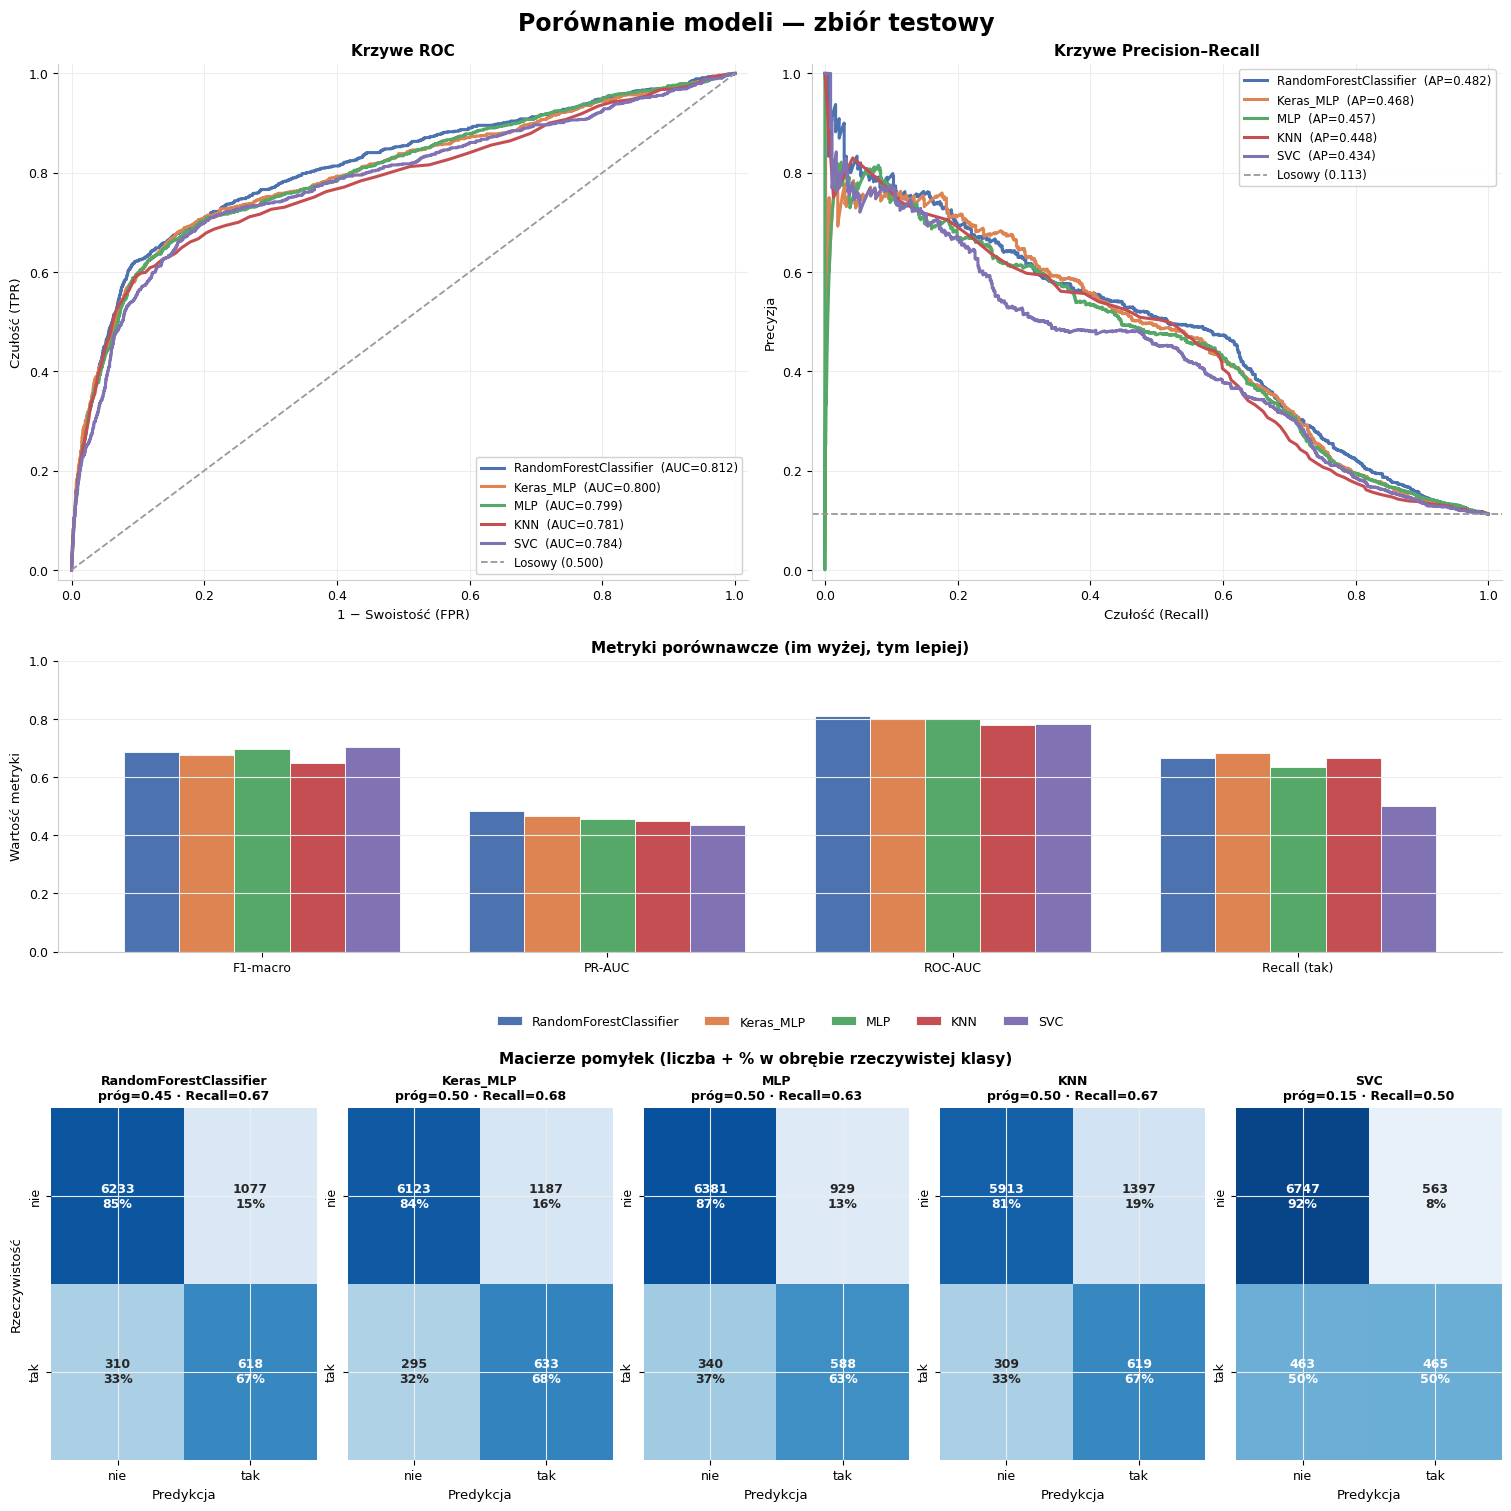

In [ ]:
# --- Setup: kolejność modeli, kolory, zmienne pomocnicze ---
order      = sorted(test_results, key=lambda k: test_results[k]['pr_auc'], reverse=True)
palette    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
colors     = {name: palette[i] for i, name in enumerate(order)}
n_models   = len(order)
prevalence = float(np.mean(y_test))   # baseline dla krzywej PR (losowy klasyfikator)

with plt.rc_context({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#cccccc',
    'axes.grid':         True,
    'grid.color':        '#ededed',
    'grid.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.titleweight':  'bold',
    'axes.labelsize':    9.5,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
}):
    fig = plt.figure(figsize=(15, 15.0), facecolor='white', layout='constrained')
    fig.suptitle("Porównanie modeli — zbiór testowy", fontsize=17, fontweight='bold')
    sf_top, sf_mid, sf_bot = fig.subfigures(3, 1, height_ratios=[1.05, 0.72, 0.82])

    # ----------------------------------------------------
    # SEKCJA 1: Krzywe ROC oraz Precision-Recall (GÓRA)
    # ----------------------------------------------------
    ax_roc, ax_pr = sf_top.subplots(1, 2)

    for name in order:
        r = test_results[name]
        fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
        ax_roc.plot(fpr, tpr, color=colors[name], lw=2.2, label=f"{name}  (AUC={r['auc']:.3f})")

        prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
        ax_pr.plot(rec, prec, color=colors[name], lw=2.2, label=f"{name}  (AP={r['pr_auc']:.3f})")

    ax_roc.plot([0, 1], [0, 1], '--', color='#999999', lw=1.3, label='Losowy (0.500)')
    ax_roc.set(xlim=(-0.02, 1.02), ylim=(-0.02, 1.02),
               xlabel='1 − Swoistość (FPR)', ylabel='Czułość (TPR)', title='Krzywe ROC')
    ax_roc.legend(loc='lower right', fontsize=8.5, framealpha=0.92)

    ax_pr.axhline(prevalence, ls='--', color='#999999', lw=1.3, label=f'Losowy ({prevalence:.3f})')
    ax_pr.set(xlim=(-0.02, 1.02), ylim=(-0.02, 1.02),
              xlabel='Czułość (Recall)', ylabel='Precyzja', title='Krzywe Precision–Recall')
    ax_pr.legend(loc='upper right', fontsize=8.5, framealpha=0.92)

    # ----------------------------------------------------
    # SEKCJA 2: Wykres słupkowy metryk (ŚRODEK)
    # ----------------------------------------------------
    ax_bar = sf_mid.subplots(1, 1)
    metryki_nazwy = ['F1-macro', 'PR-AUC', 'ROC-AUC', 'Recall (tak)']
    x_pos     = np.arange(len(metryki_nazwy))
    bar_width = 0.8 / n_models

    for i, name in enumerate(order):
        r      = test_results[name]
        wartosci = [r['f1'], r['pr_auc'], r['auc'], r['recall']]
        offset = -0.4 + bar_width * (i + 0.5)
        ax_bar.bar(x_pos + offset, wartosci, width=bar_width,
                   color=colors[name], edgecolor='white', linewidth=0.6, label=name)

    ax_bar.set(xticks=x_pos, ylim=(0, 1),
               ylabel='Wartość metryki', title='Metryki porównawcze (im wyżej, tym lepiej)')
    ax_bar.set_xticklabels(metryki_nazwy)
    ax_bar.grid(axis='x', visible=False)
    ax_bar.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18),
                  ncol=n_models, fontsize=9, frameon=False)

    # ----------------------------------------------------
    # SEKCJA 3: Macierze Pomyłek (DÓŁ)
    # ----------------------------------------------------
    axes_cm = sf_bot.subplots(1, n_models)
    if n_models == 1:
        axes_cm = [axes_cm]

    sf_bot.suptitle("Macierze pomyłek (liczba + % w obrębie rzeczywistej klasy)",
                    fontsize=11, fontweight='bold')

    for ax, name in zip(axes_cm, order):
        r   = test_results[name]
        cm  = r['cm']
        cmn = cm / cm.sum(axis=1, keepdims=True)  # normalizacja wierszowa → przekątna = recall

        labels = np.array([
            [f"{cm[0,0]}\n{cmn[0,0]:.0%}", f"{cm[0,1]}\n{cmn[0,1]:.0%}"],
            [f"{cm[1,0]}\n{cmn[1,0]:.0%}", f"{cm[1,1]}\n{cmn[1,1]:.0%}"]
        ])
        sns.heatmap(cmn, annot=labels, fmt='', cmap='Blues', cbar=False,
                    xticklabels=['nie', 'tak'], yticklabels=['nie', 'tak'],
                    vmin=0, vmax=1, ax=ax, annot_kws={'fontsize': 9, 'fontweight': 'bold'})

        ax.set_title(f"{name}\npróg={r['threshold']:.2f} · Recall={r['recall']:.2f}", fontsize=9)
        ax.set_xlabel('Predykcja')
        ax.set_ylabel('')

    axes_cm[0].set_ylabel('Rzeczywistość')

    fig.savefig(os.path.join(sciezka_wykresow, 'analiza_porownawcza_modele.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

In [1]:
rng = np.random.default_rng(RANDOM_STATE)
N_REPEATS = 10
feature_cols = X_test.columns.tolist()        # 15 surowych cech

def proba(name, X_raw):                        # jednolite P(yes) dla każdego modelu
    est = results[name]['estimator']
    if name == 'Keras_MLP':
        Xt = preprocessor.transform(X_raw)
        if scipy.sparse.issparse(Xt): Xt = Xt.toarray()
        return est.predict(Xt, verbose=0).ravel()
    return est.predict_proba(X_raw)[:, 1]

perm = {}
for name in results:
    base = average_precision_score(y_test, proba(name, X_test))
    perm[name] = {}
    for col in feature_cols:
        drops = []
        for _ in range(N_REPEATS):
            Xp = X_test.copy()
            Xp[col] = rng.permutation(Xp[col].values)
            drops.append(base - average_precision_score(y_test, proba(name, Xp)))
        perm[name][col] = np.mean(drops)
    print(f"✅ {name} (bazowy PR-AUC={base:.4f})")

fi = pd.DataFrame(perm)
fi['ŚREDNIA'] = fi.mean(axis=1)
fi = fi.sort_values('ŚREDNIA', ascending=False)
print("\n" + fi.round(4).to_string())

# Wykres: panel na każdy model, top 8 cech
COLORS = {'RandomForestClassifier':'#4C72B0','Keras_MLP':'#DD8452',
          'MLP':'#55A868','KNN':'#C44E52','SVC':'#8172B3'}
models = [m for m in fi.columns if m != 'ŚREDNIA']
fig, axes = plt.subplots(1, len(models), figsize=(22, 6))
for ax, name in zip(axes, models):
    top = fi[name].sort_values(ascending=False).head(8)[::-1]
    ax.barh(top.index, top.values, color=COLORS.get(name, 'gray'))
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.axvline(0, color='k', lw=0.5); ax.tick_params(labelsize=9)
fig.suptitle('Ważność cech — permutation importance (spadek PR-AUC po przetasowaniu)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

NameError: name 'np' is not defined

# 7. Wnioski



## Najważniejsze obserwacje:

- **RandomForest** ma najlepsze metryki rankingowe niezależne od progu — PR-AUC 0,483 i ROC-AUC 0,812. Najlepiej rozróżnia i rankinguje klientów.
- **SVC** po doborze progu osiąga najwyższy F1-macro (0,702) oraz **najmniej zbędnych telefonów (563 FP)**. To największa transformacja: przy domyślnym progu 0,5 miał Recall zaledwie 0,19 (176 TP), a obniżenie progu do 0,147 podniosło Recall do 0,50 i dodało 289 trafionych klientów. SVC ma też najlepszą kalibrację prawdopodobieństw (Brier 0,082).
- **Keras_MLP** osiąga najwyższą czułość (0,682) — wykrywa najwięcej klientów (633), ale kosztem największej liczby fałszywych alarmów (1187 FP).
- Różnice między modelami są niewielkie: F1-macro w przedziale 0,65–0,70, PR-AUC 0,43–0,48, ROC-AUC 0,78–0,81.

## Rekomendacja

Rekomendacja zależy od celu biznesowego:

- **Do rankowania i priorytetyzacji listy klientów: RandomForest.** Wygrywa metrykę główną projektu (PR-AUC 0,483) oraz ROC-AUC (0,812), czyli najlepiej sortuje klientów według prawdopodobieństwa konwersji. Dodatkowo jest w pełni interpretowalny (feature importance), nie wymaga skalowania i jest stabilny w trenowaniu.

- **Do wdrożenia przy stałym progu i ograniczonej przepustowości call center: SVC.** Po doborze progu osiąga najwyższy F1-macro (0,702), najmniej zbędnych telefonów (563 FP) i najlepszą kalibrację. Jego słabością jest niższa czułość (0,50) — pomija więcej klientów niż RandomForest.

- **Do maksymalnego pokrycia rynku (gdy priorytetem jest złapanie jak największej liczby klientów): Keras_MLP lub KNN** — czułość ~0,67–0,68, ale kosztem ponad 1300 zbędnych telefonów.


## Wnioski metodologiczne

- Przy niezbalansowaniu 89/11 **accuracy jest myląca** — kluczowe są PR-AUC i F-score. Losowy klasyfikator osiąga PR-AUC = 0,113; wszystkie modele przekroczyły 0,43, czyli były ~4× lepsze od losowego.
- **Usunięcie `duration`** obniżyło metryki, ale uczyniło model realistycznym — to świadoma decyzja przeciw wyciekowi danych. Z tą cechą ROC-AUC sięgałoby ~0,93, ale wynik byłby nieosiągalny w praktyce.
- **Kierunek doboru progu zależy od kalibracji modelu.** SVC (z `class_weight`, dobrze skalibrowany) wymagał drastycznego obniżenia progu do 0,147, co dało +289 trafionych klientów. Modele trenowane SMOTE (MLP, Keras, KNN) mają zawyżone prawdopodobieństwa klasy mniejszościowej, przez co ich optymalny próg F2 pozostał na poziomie 0,5 (ograniczenie z góry zadziałało).
- **Wszystkie modele osiągnęły zbliżony wynik**, co wskazuje na wyczerpanie sygnału zawartego w cechach — bottleneck leży w danych, nie w modelach; dalsze strojenie hiperparametrów dałoby marginalną poprawę.
